In [246]:
words=open('names.txt').read().splitlines()


In [247]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [248]:
lengths = []
for w in words:
    lengths.append(len(w))
print(max(lengths))
    

15


In [249]:
min(len(i)for i in words)
 

2

In [250]:
max(len(j) for j in words)

15

In [251]:
len(words)

32033

In [252]:
eg=["emma","sudha","soman"]

In [253]:
w

'zzyzx'

In [254]:

b={}
for w in words:
     
     chs=['.']+list(w)+['.']
     for ch1, ch2 in zip(chs, chs[1:]):
        
         bigram=(ch1,ch2)
         b[bigram]=b.get(bigram,0)+1

In [255]:
len(b)

627

In [256]:
import torch

N=torch.zeros((27,27),dtype=torch.int32)



In [257]:
chars=sorted(list(set(''.join(words))))
stoi= {s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
print(stoi)


{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}


In [258]:

for w in words:
     
     chs=['.']+list(w)+['.']
     for ch1, ch2 in zip(chs, chs[1:]):
         ix1=stoi[ch1]
         ix2=stoi[ch2]
         N[ix1,ix2]+=1 

In [259]:
itos={i:s for s,i in stoi.items()}

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

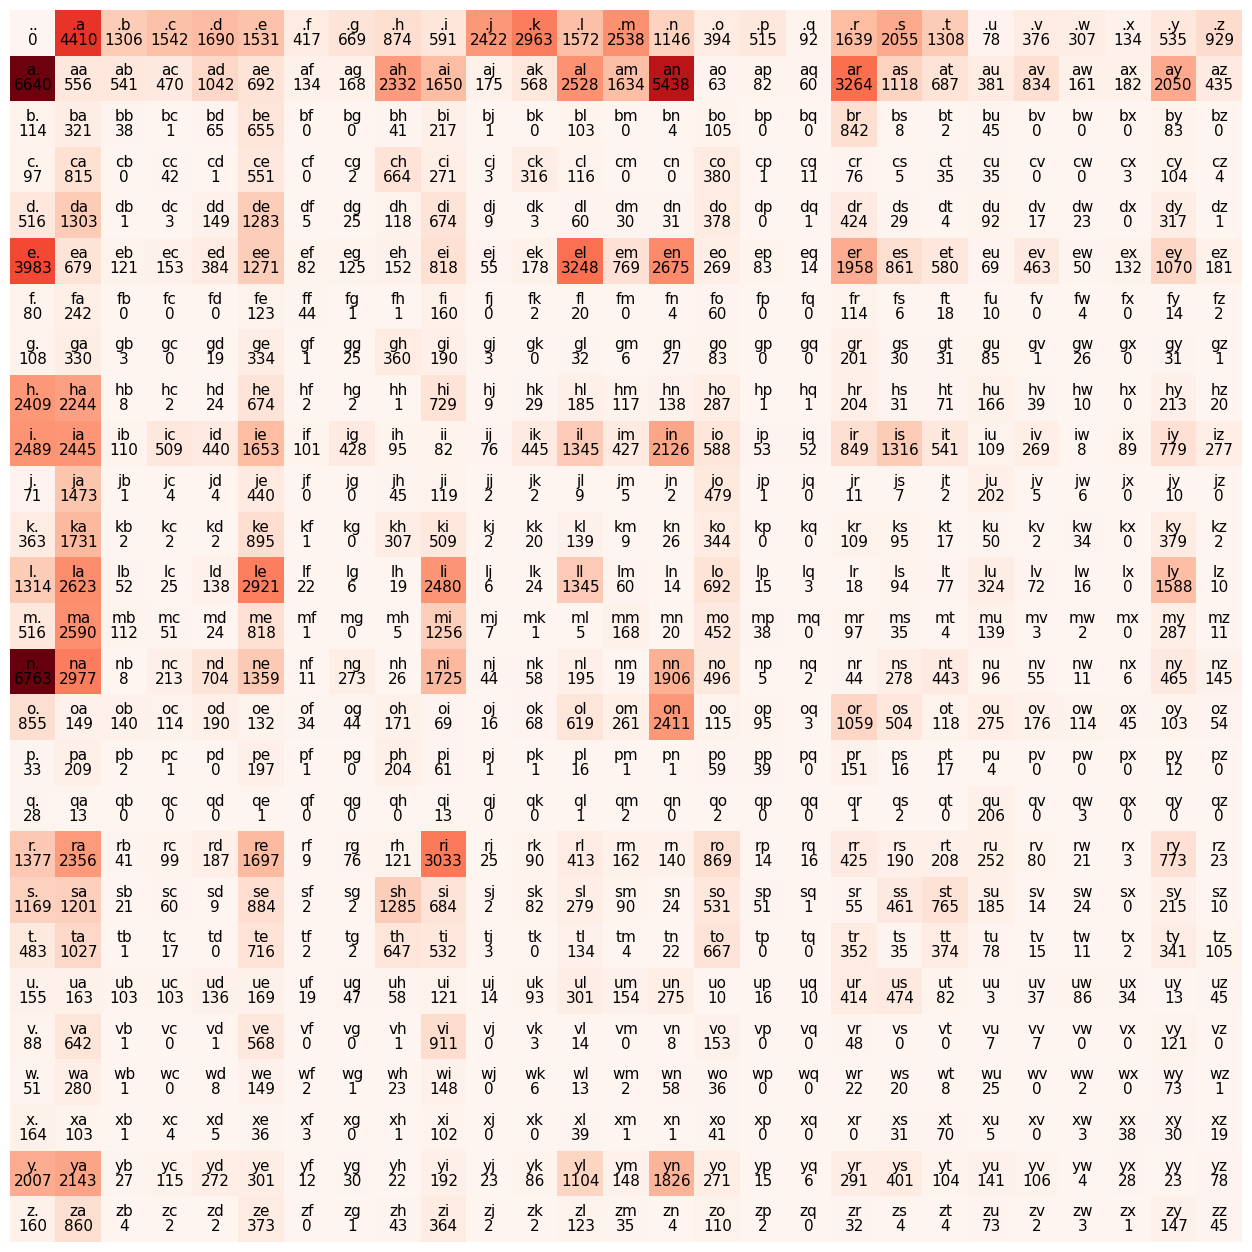

In [260]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Reds')

for i in range(27):          # i = row index
    for j in range(27):      # j = column index
        chstr = itos[i] + itos[j]   # turn (i, j) into the actual bigram, e.g. "em"

        # x=j (column → across), y=i (row → down)
        # this draws the bigram text, sitting toward the bottom of the cell
        plt.text(j, i, chstr, ha='center', va='bottom', fontsize=11)

        # same (x, y) position, but this draws the count number instead,
        # sitting toward the top of the cell — so label and count stack without overlapping
        plt.text(j, i, N[i,j].item(), ha='center', va='top', fontsize=11)



plt.axis('off')   # hides the x/y axis ticks and numbers, since we don't need them

In [261]:

N.shape


torch.Size([27, 27])

In [262]:
print(sorted(itos.keys()))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]


In [263]:
P = (N+1).float()
P = P / P.sum(1, keepdim=True)

In [264]:
print(P[0].sum())

tensor(1.)


In [265]:
g= torch.Generator().manual_seed(2147483647)
for i in range(5):
    out=[]
    ix=0
    while True:
        p = N[ix].float()
        p = p / p.sum()
        
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        if ix == 0:
    
            break
        out.append(itos[ix])
    print(''.join(out))

junide
janasah
p
cony
a


In [ ]:
log_likelihood=0
n=0

for w in words:
     
     chs=['.']+list(w)+['.']
     for ch1, ch2 in zip(chs, chs[1:]):
         ix1=stoi[ch1]
         ix2=stoi[ch2]
         prob=P[ix1,ix2]
         logprob=torch.log(prob)
         log_likelihood+=logprob
         n+=1
        

print(f'{log_likelihood}')
neg_log_likelihood=-log_likelihood
nll=neg_log_likelihood
print(nll)
print(f'{nll/n}')

In [267]:
P.shape

torch.Size([27, 27])

In [268]:
# ALTERNATIVE APPROACH

In [269]:
# creatye the training set

xs,ys=[],[]

for w in words:
     
     chs=['.']+list(w)+['.']
     for ch1, ch2 in zip(chs, chs[1:]):
         ix1=stoi[ch1]
         ix2=stoi[ch2]
         N[ix1,ix2]+=1 
         xs.append(ix1)
         ys.append(ix2)

xs=torch.tensor(xs)
ys=torch.tensor(ys)
num=len(xs)
num


228146

In [298]:
# Creating W..which is random...but constant selection because of the generator
g= torch.Generator().manual_seed(2147483647)
W=torch.randn((27,27),generator=g,requires_grad=True) 


In [ ]:
import torch.nn.functional as F
# Forward pass it is
for i in range(200):

    xenc=F.one_hot(xs,num_classes=27).float()
    logits=xenc @ W
    counts=logits.exp()  #it is equilant to the N matrix we did earlier
    probs=counts/counts.sum(1,keepdim=True)
    loss=-probs[torch.arange(num),ys].log().mean()
    print(loss.item())


    # Backward pass
    W.grad=None
    loss.backward()
    
    # update the gradient
    W.data+=-20 * W.grad


2.4585840702056885
2.458578109741211
2.458571672439575
2.4585659503936768
2.458559989929199
2.4585540294647217
2.458547830581665
2.4585421085357666
2.458536148071289
2.4585301876068115
2.458524465560913
2.4585182666778564
2.458512544631958
2.4585065841674805
2.458500623703003
2.4584946632385254
2.458488941192627
2.4584829807281494
2.45847749710083
2.4584715366363525
2.458465814590454
2.4584600925445557
2.458454132080078
2.4584484100341797
2.4584426879882812
2.458437204360962
2.4584314823150635
2.458425760269165
2.4584200382232666
2.458414316177368
2.458408832550049
2.4584033489227295
2.458397626876831
2.4583916664123535
2.4583866596221924
2.458380699157715
2.4583754539489746
2.458369493484497
2.458364486694336
2.4583585262298584
2.458353042602539
2.4583475589752197
2.4583420753479004
2.4583370685577393
2.458331346511841
2.4583258628845215
2.458320379257202
2.458314895629883
2.4583096504211426
2.4583041667938232
2.458298683166504
2.4582934379577637
2.4582881927490234
2.458282709121704
2

In [ ]:
g= torch.Generator().manual_seed(2147483647)
for i in range(5):
    out=[]
    ix=0
    while True:
         xenc=F.one_hot(torch.tensor([ix]),num_classes=27).float()
         logits=xenc @ W
         counts=logits.exp()  #it is equilant to the N matrix we did earlier
         probs=counts/counts.sum(1,keepdim=True)
       
         ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
         out.append(itos[ix])
         if ix == 0:
    
            break
         
    print(''.join(out))